In [1]:
import requests
import pandas as pd
import io

def extract_titanic_data():
    # 타이타닉 데이터 공개 URL
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

    response = requests.get(url)
    if response.status_code == 200:
        # 문자열 데이터를 파일처럼 취급하여 pandas로 읽기
        data = pd.read_csv(io.StringIO(response.text))
        print("데이터 추출 성공!")
        return data
    else:
        print("데이터를 불러오지 못했습니다.")
        return None

df = extract_titanic_data()

데이터 추출 성공!


In [2]:
# 1. 데이터 상위 5행 확인
print(df.head())

# 2. 데이터 요약 정보 (결측치, 데이터 타입 확인)
print(df.info())

# 3. 간단한 통계 분석 (생존율 등)
survival_rate = df['Survived'].mean() * 100
print(f"평균 생존율: {survival_rate:.2f}%")

# 4. 성별에 따른 생존자 수 합계
gender_survival = df.groupby('Sex')['Survived'].sum()
print(gender_survival)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
<c

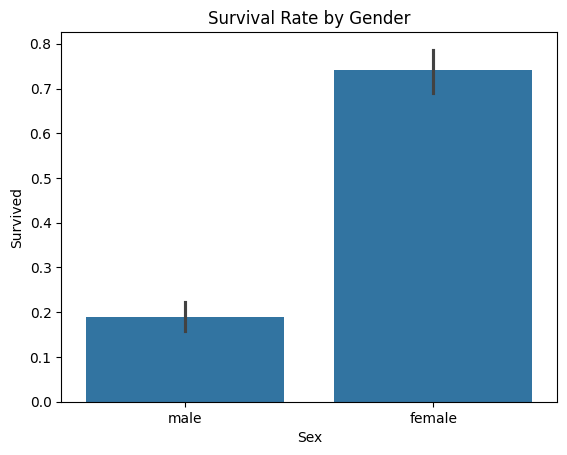

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 성별 생존율 시각화
sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Survival Rate by Gender')
plt.show()